<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Goal" data-toc-modified-id="Goal-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Goal</a></span></li><li><span><a href="#Var" data-toc-modified-id="Var-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Var</a></span></li><li><span><a href="#Init" data-toc-modified-id="Init-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Init</a></span></li><li><span><a href="#Load" data-toc-modified-id="Load-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Load</a></span></li><li><span><a href="#Procrustes" data-toc-modified-id="Procrustes-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Procrustes</a></span><ul class="toc-item"><li><span><a href="#Sum-of-squares" data-toc-modified-id="Sum-of-squares-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Sum of squares</a></span></li><li><span><a href="#Residuals" data-toc-modified-id="Residuals-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Residuals</a></span></li></ul></li><li><span><a href="#Protest" data-toc-modified-id="Protest-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Protest</a></span></li><li><span><a href="#sessionInfo" data-toc-modified-id="sessionInfo-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>sessionInfo</a></span></li></ul></div>

# Goal

* Compare all beta-div distance matrices via procrustes
* Assess how procrustes residuals group by dataset & metadata group
  * The analysis will help reveal differences in phylogenetic and trait relatedness among groups

# Var

In [1]:
# working dir
work_dir = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/'

# PCoA objects
## phylogeny
phy_pcoa_file = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/beta-div_pcoa.qs'
## traits 
trt_pcoa_file = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/beta-div_trt-maj.qs'

## filtered
metadata_filt_file = file.path(work_dir, 'CurMetDat_metadata_filt-n1846.tsv')
## all 
base_in_dir = '/ebio/abt3_projects/small_projects/nyoungblut/public_data_retireval/'
metadata_file = file.path(base_in_dir, 'CurMetDat-metagenomes', 'files', 'metadata', 'Filtered_CurMetDat_f.tsv')

# params
threads = 16

# Init

In [5]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(data.table)
library(dtplyr)
library(tidytable)
library(purrr)
library(ape)
library(phyloseq)
library(vegan)
library(LeyLabRMisc)

In [3]:
library(future)
library(future.batchtools)
library(furrr)
options(future.wait.interval = 2.0)

In [4]:
df.dims()
setDTthreads(threads)

# Load

In [6]:
# reading in phylogeny-based PCoA
phy_pcoa = qs::qread(phy_pcoa_file, nthreads=threads)
names(phy_pcoa) = c('bray', 'jaccard', 'wunifrac_phy', 'unifrac_phy')
phy_pcoa %>% length

[1] 4

In [7]:
# reading in trait-based PCoA
trt_pcoa = qs::qread(trt_pcoa_file, nthreads=threads) 
names(trt_pcoa) = c('wunifrac_trt', 'unifrac_trt')
trt_pcoa %>% length

[1] 2

In [8]:
# combining
pcoa_all = c(phy_pcoa, trt_pcoa)
pcoa_all %>% names

[1] "bray"         "jaccard"      "wunifrac_phy" "unifrac_phy"  "wunifrac_trt"
[6] "unifrac_trt"

In [9]:
# all  metadata
meta = Fread(metadata_file) %>%
    dt_mutate(Sample = gsub('-', '.', Sample))
meta %>% unique_n('Samples', Sample)
meta

No. of unique Samples: 3594 


dataset_name,Sample,subjectID,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,⋯,il_1,glp_1,travel_destination,urea_nitrogen,disease_stage,uncurated_metadata,family_member,subject_n,samp_n,westernized
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<lgl>
AsnicarF_2017,MV_FEM1_t1Q14,MV_FEM1,stool,NA,control,healthy,NA,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
AsnicarF_2017,MV_FEM2_t1Q14,MV_FEM2,stool,NA,control,healthy,NA,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
ZellerG_2014,CCIS82944710ST.20.0,FR-730,stool,NA,control,healthy,38,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
ZellerG_2014,CCIS93040568ST.20.0,FR-682,stool,NA,control,healthy,65,adult,male,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE


In [10]:
# filtered
meta_f = Fread(metadata_filt_file) %>%
    dt_mutate(Sample = gsub('-', '.', Sample))
meta_f %>% unique_n('Samples', Sample)
meta_f

No. of unique Samples: 1846 


dataset,Sample,Run,Lane,Remote,subjectID,body_site,antibiotics_current_use,study_condition,disease,⋯,il_1,glp_1,travel_destination,urea_nitrogen,disease_stage,uncurated_metadata,family_member,subject_n,samp_n,westernized
<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<lgl>,<chr>,<lgl>,<int>,<int>,<lgl>
Bengtsson-PalmeJ_2015,TRAVELRES1,1,1,ERR636349,TRAVELRES1_2,stool,no,control,healthy,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
Bengtsson-PalmeJ_2015,TRAVELRES10,1,1,ERR636358,TRAVELRES9_10,stool,no,control,healthy,⋯,NA,NA,LKA,NA,NA,NA,NA,1,1,TRUE
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
YeZ_2018,YEZ_N.38,1,1,SRR8675918,YEZ_N-38,stool,no,control,healthy,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
YeZ_2018,YEZ_N.37,1,1,SRR8675921,YEZ_N-37,stool,no,control,healthy,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE


# Procrustes

In [11]:
dists = c('bray', 'jaccard', 'wunifrac_phy', 'unifrac_phy', 'wunifrac_trt', 'unifrac_trt')

In [11]:
# pairwise Procrustes
run_proc = function(x, pcoa_list){
    x = as.character(as.matrix(x))
    vegan::procrustes(pcoa_list[[x[1]]], pcoa_list[[x[2]]], symmetric=TRUE)
}

## creating pairwise set
pairwise_dists = expand.grid(dists,dists) %>%
    filter(Var1 != Var2) 
cat('Number of pairwise comparisons:', nrow(pairwise_dists), '\n')

## run in parallel 
doParallel::registerDoParallel(8)
proc_all = pairwise_dists %>%  
    #head(n=3) %>%   # debug
    split(seq(nrow(.))) %>%
    plyr::llply(run_proc, pcoa_list=pcoa_all, .parallel=FALSE)

proc_all %>% length

Number of pairwise comparisons: 30 


Warning message in vegan::procrustes(pcoa_list[[x[1]]], pcoa_list[[x[2]]], symmetric = TRUE):
“X has fewer axes than Y: X adjusted to comform Y
”
Warning message in vegan::procrustes(pcoa_list[[x[1]]], pcoa_list[[x[2]]], symmetric = TRUE):
“X has fewer axes than Y: X adjusted to comform Y
”
Warning message in vegan::procrustes(pcoa_list[[x[1]]], pcoa_list[[x[2]]], symmetric = TRUE):
“X has fewer axes than Y: X adjusted to comform Y
”
Warning message in vegan::procrustes(pcoa_list[[x[1]]], pcoa_list[[x[2]]], symmetric = TRUE):
“X has fewer axes than Y: X adjusted to comform Y
”
Warning message in vegan::procrustes(pcoa_list[[x[1]]], pcoa_list[[x[2]]], symmetric = TRUE):
“X has fewer axes than Y: X adjusted to comform Y
”
Warning message in vegan::procrustes(pcoa_list[[x[1]]], pcoa_list[[x[2]]], symmetric = TRUE):
“X has fewer axes than Y: X adjusted to comform Y
”
Warning message in vegan::procrustes(pcoa_list[[x[1]]], pcoa_list[[x[2]]], symmetric = TRUE):
“X has fewer axes than Y: X ad

[1] 30

In [12]:
# adding names to list
L_names = pairwise_dists %>% unite(dist_comp, Var1, Var2, sep=':') %>% .$dist_comp
names(proc_all) = L_names[1:length(proc_all)]
names(proc_all) %>% head

[1] "jaccard:bray"      "wunifrac_phy:bray" "unifrac_phy:bray" 
[4] "wunifrac_trt:bray" "unifrac_trt:bray"  "bray:jaccard"

In [13]:
# saving results
procrustes_file = file.path(work_dir, 'beta-div_procrustes-sym.qs')
qs::qsave(proc_all, procrustes_file, nthreads=threads)
cat('File written:', procrustes_file, '\n')

File written: /ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity//beta-div_procrustes-sym.qs 


In [12]:
# re-loading results
procrustes_file = file.path(work_dir, 'beta-div_procrustes-sym.qs')
proc_all = qs::qread(procrustes_file, nthreads=threads)
proc_all %>% length

[1] 30

## Sum of squares

In [13]:
# getting sums of squares
proc_all_ss = proc_all %>%
    plyr::llply(function(x) x$ss) %>%
    do.call(rbind, .) %>%
    as.data.frame
                
proc_all_ss$dists = rownames(proc_all_ss)
proc_all_ss = proc_all_ss %>%
    separate(dists, c('dist_x', 'dist_y'), sep=':')
                
proc_all_ss

,V1,dist_x,dist_y
,<dbl>,<chr>,<chr>
jaccard:bray,0.02732053,jaccard,bray
wunifrac_phy:bray,0.39919475,wunifrac_phy,bray
⋮,⋮,⋮,⋮
unifrac_phy:unifrac_trt,0.3001858,unifrac_phy,unifrac_trt
wunifrac_trt:unifrac_trt,0.3524553,wunifrac_trt,unifrac_trt


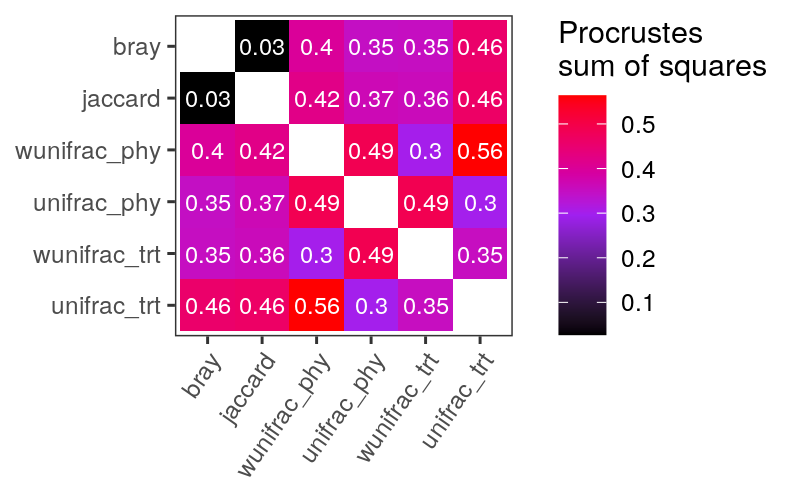

In [18]:
p = proc_all_ss %>%
    mutate(dist_x = factor(dist_x, levels=dists),
           dist_y = factor(dist_y, levels=rev(dists))) %>%
    ggplot(aes(dist_x, dist_y, fill=V1)) +
    #geom_point(alpha=0.2) + 
    #geom_point(alpha=0.5, shape='O') +
    geom_tile() +
    #scale_size_continuous('Procrustes\nsum of squares') +
    geom_text(aes(label=round(V1, 2)), color='white', size=3) +
    scale_fill_gradientn('Procrustes\nsum of squares', 
                         colors=c('black', 'purple',  'red')) +
    theme_bw() +
    theme(
        panel.grid = element_blank(),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        axis.text.x = element_text(angle=55, hjust=1)
    )

p.dims(4,2.5)
plot(p)

## Residuals

In [75]:
# getting sums of squares
doParallel::registerDoParallel(threads)
proc_all_res = proc_all %>%
    #head(n=3) %>%
    plyr::llply(function(x) x %>% residuals %>% as.data.frame, .parallel=TRUE) %>%
    do.call(rbind, .)

colnames(proc_all_res) = c('residuals')
proc_all_res$dists = rownames(proc_all_res) 
proc_all_res = proc_all_res %>%
    mutate(dists = gsub('^([A-Za-z_]+):([A-Za-z_]+)\\.(.+)', '\\1:\\2:\\3', dists)) %>%
    separate(dists, c('dist_x', 'dist_y', 'sample'), sep=':')             
                
proc_all_res

residuals,dist_x,dist_y,sample
<dbl>,<chr>,<chr>,<chr>
0.004288064,jaccard,bray,A01_02_1FE
0.003171602,jaccard,bray,A02_01_1FE
⋮,⋮,⋮,⋮
0.028697829,wunifrac_trt,unifrac_trt,YSZC12003_37879
0.009729626,wunifrac_trt,unifrac_trt,YSZC12003_37880


In [76]:
x = proc_all_res %>%
    dt_inner_join(combn(dists, 2) %>% t %>% as.data.frame, 
                  c('dist_x'='V2', 'dist_y'='V1'))
proc_all_res = dt_bind_rows(x, x %>% 
                            dt_rename('dist_X' = dist_y, 'dist_y' = dist_x) %>%
                            dt_rename('dist_x' = 'dist_X'))
proc_all_res

residuals,dist_x,dist_y,sample
<dbl>,<chr>,<chr>,<chr>
0.004288064,jaccard,bray,A01_02_1FE
0.003171602,jaccard,bray,A02_01_1FE
⋮,⋮,⋮,⋮
0.022508902,wunifrac_trt,unifrac_trt,YSZC12003_37879
0.009600827,wunifrac_trt,unifrac_trt,YSZC12003_37880


In [77]:
# checking key overlap
overlap(proc_all_res$sample, meta %>% dt_pull(Sample))

intersect(x,y): 3357 
setdiff(x,y): 0 
setdiff(y,x): 237 
union(x,y): 3594 


In [78]:
# adding metadata
proc_all_res = proc_all_res %>%
    as.data.table %>%
    dt_rename('Sample'=sample) %>%
    dt_inner_join(meta, by=c('Sample')) %>%
    as.data.frame %>%
    as.data.table

proc_all_res

residuals,dist_x,dist_y,Sample,dataset_name,subjectID,body_site,antibiotics_current_use,study_condition,disease,⋯,il_1,glp_1,travel_destination,urea_nitrogen,disease_stage,uncurated_metadata,family_member,subject_n,samp_n,westernized
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<lgl>
0.006294815,jaccard,bray,MV_FEM1_t1Q14,AsnicarF_2017,MV_FEM1,stool,NA,control,healthy,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
0.014500912,wunifrac_phy,bray,MV_FEM1_t1Q14,AsnicarF_2017,MV_FEM1,stool,NA,control,healthy,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
0.005290201,unifrac_phy,unifrac_trt,PNP_Validation_46,ZeeviD_2015,PNP_Validation_46,stool,no,control,healthy,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
0.005970788,wunifrac_trt,unifrac_trt,PNP_Validation_46,ZeeviD_2015,PNP_Validation_46,stool,no,control,healthy,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE


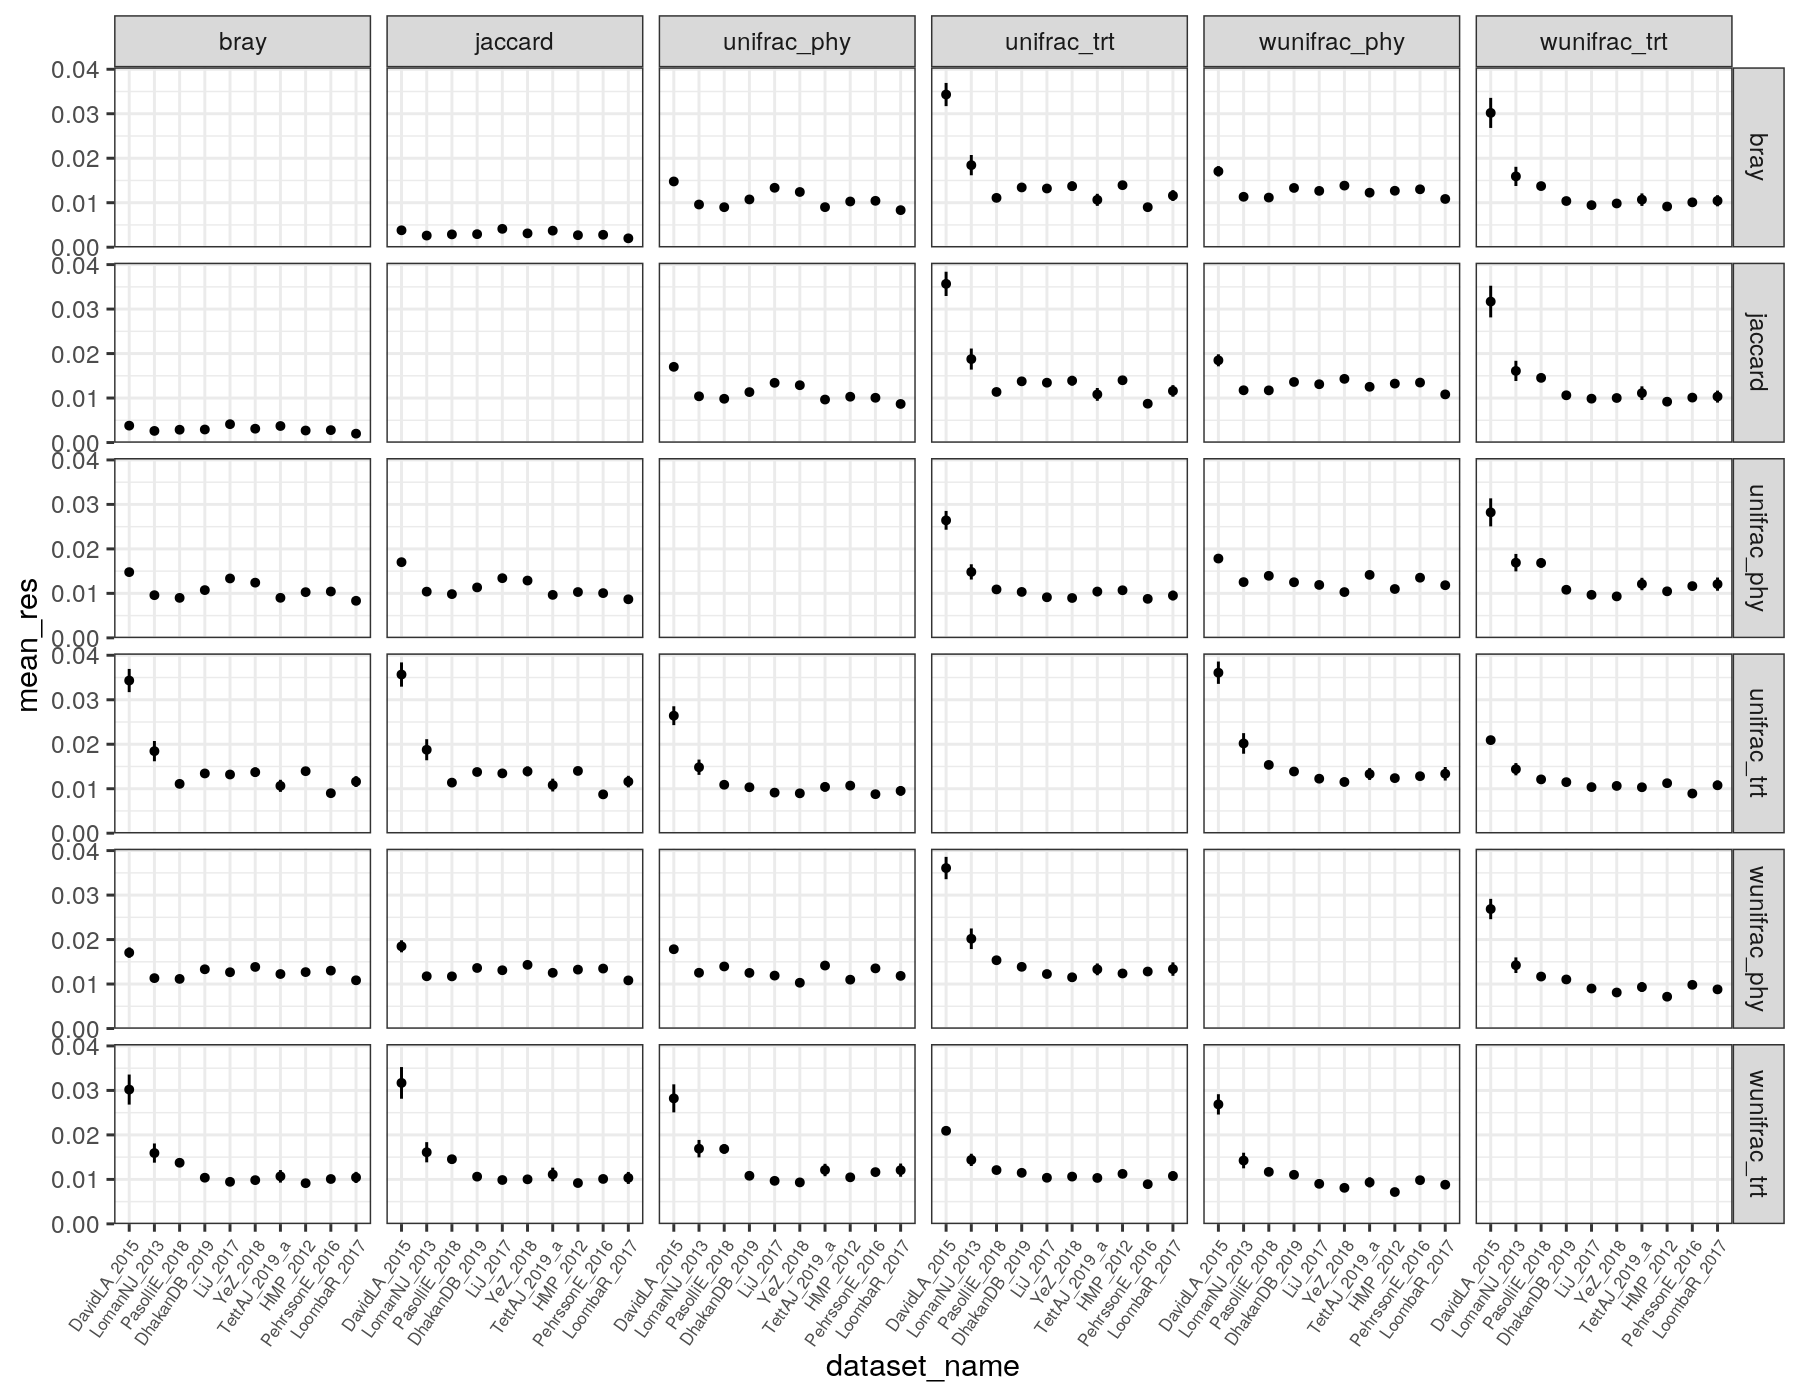

In [79]:
# plotting
p = proc_all_res %>%
    dt_mutate(total_mean_res = mean(residuals),
              by=c(dataset_name)) %>%
    dt_summarize(mean_res = mean(residuals),
                 sd_res = sd(residuals) / sqrt(length(residuals)), 
                 by=c(dist_x, dist_y, dataset_name, total_mean_res)) %>%
    dt_filter(total_mean_res >= 0.01) %>%
    dt_mutate(dataset_name = reorder(dataset_name, -total_mean_res)) %>%
    ggplot(aes(dataset_name, mean_res)) +
    geom_linerange(aes(ymin=mean_res-sd_res,
                       ymax=mean_res+sd_res)) +
    geom_point(size=1) +
    facet_grid(dist_y ~ dist_x) +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=55, hjust=1, size=6)
    )

p.dims(9,7)
plot(p)

In [80]:
# formatting
proc_all_res_s = proc_all_res %>%
    dt_filter(!is.na(disease)) %>%
    dt_mutate(total_mean_res = mean(residuals),
              by=c(disease)) %>%
    dt_summarize(mean_res = mean(residuals),
                 sd_res = sd(residuals) / sqrt(length(residuals)), 
                 by=c(dist_x, dist_y, disease, total_mean_res, study_condition))

proc_all_res_s 

dist_x,dist_y,disease,total_mean_res,study_condition,mean_res,sd_res
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
jaccard,bray,healthy,0.009089521,control,0.002417336,3.084753e-05
wunifrac_phy,bray,healthy,0.009089521,control,0.009599330,8.517388e-05
⋮,⋮,⋮,⋮,⋮,⋮,⋮
unifrac_phy,unifrac_trt,fatty_liver,0.01019018,fatty_liver,0.009515916,0.001076939
wunifrac_trt,unifrac_trt,fatty_liver,0.01019018,fatty_liver,0.010767721,0.001057482


Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning mess

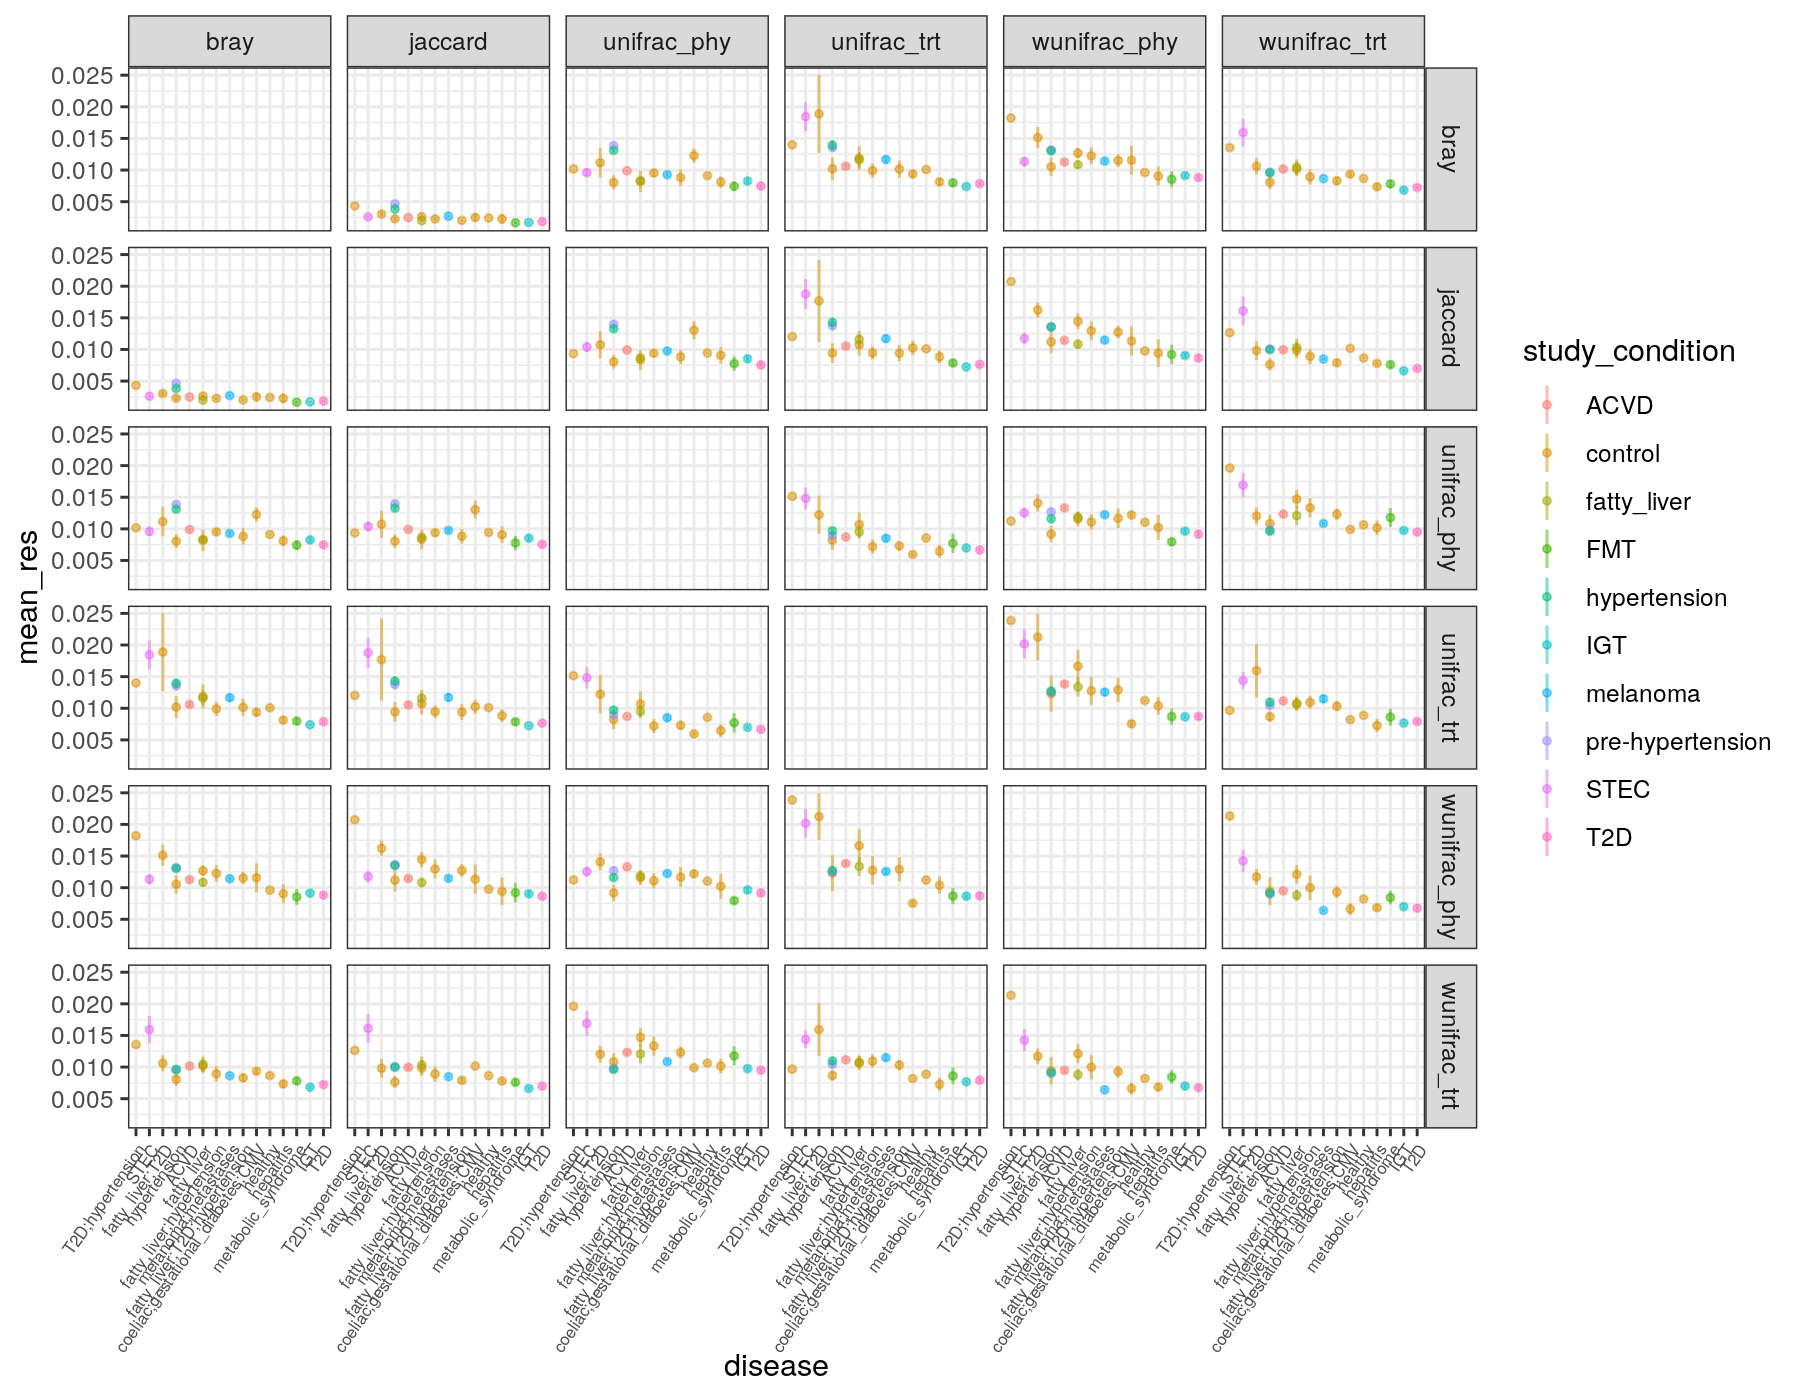

In [81]:
# plotting
p = proc_all_res_s %>%
    dt_mutate(disease = reorder(disease, -total_mean_res)) %>%
    ggplot(aes(disease, mean_res, color=study_condition)) +
    geom_linerange(aes(ymin=mean_res-sd_res,
                       ymax=mean_res+sd_res), alpha=0.5) +
    geom_point(size=1, alpha=0.5) +
    facet_grid(dist_y ~ dist_x) +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=55, hjust=1, size=6)
    )

p.dims(9,7)
plot(p)

Warning message:
“Removed 5 rows containing missing values (geom_segment).”
Warning message:
“Removed 5 rows containing missing values (geom_segment).”
Warning message:
“Removed 5 rows containing missing values (geom_segment).”
Warning message:
“Removed 5 rows containing missing values (geom_segment).”
Warning message:
“Removed 5 rows containing missing values (geom_segment).”
Warning message:
“Removed 5 rows containing missing values (geom_segment).”


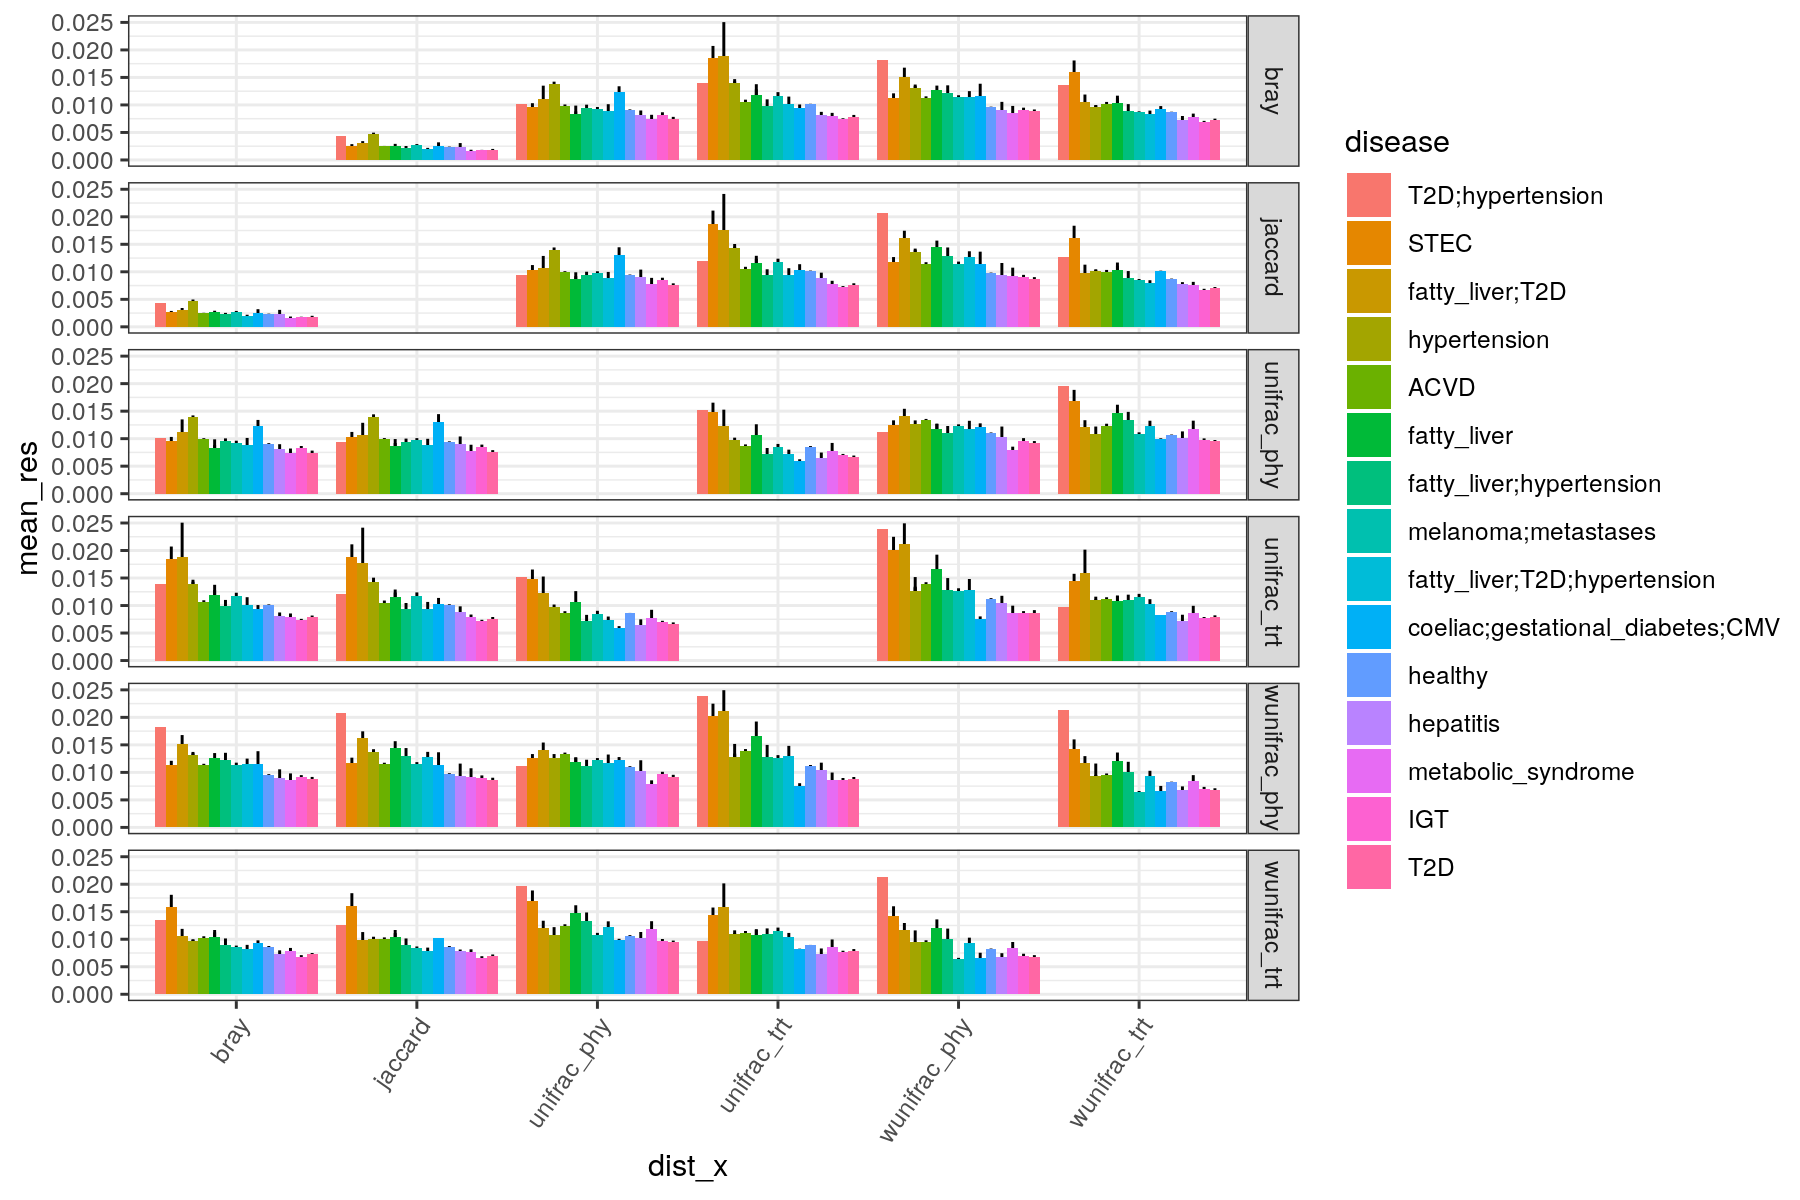

In [82]:
# plotting
p = proc_all_res_s %>%
    dt_mutate(disease = reorder(disease, -total_mean_res)) %>%
    ggplot(aes(dist_x, mean_res, fill=disease)) +
    geom_linerange(aes(ymin=mean_res-sd_res,
                       ymax=mean_res+sd_res),
                   position=position_dodge(width=0.9)) +
    geom_bar(stat='identity', position='dodge') +
    facet_grid(dist_y ~ .) +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=55, hjust=1)
    )

p.dims(9,6)
plot(p)

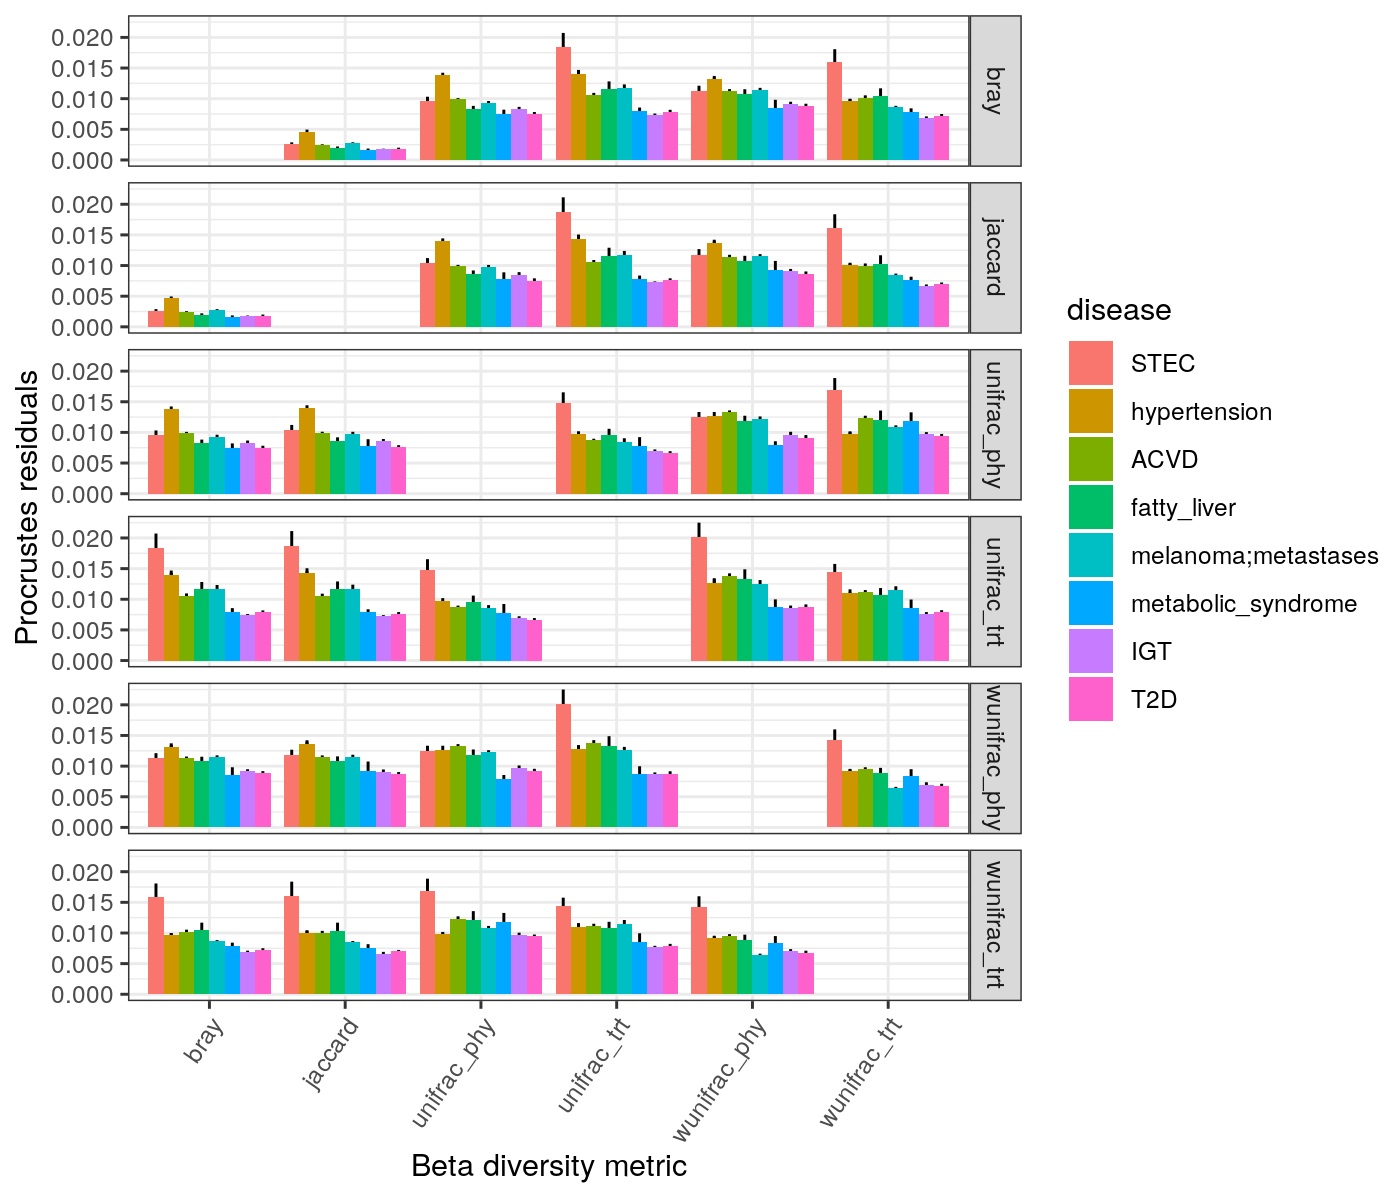

In [83]:
# plotting
p = proc_all_res_s %>%
    dt_filter(study_condition != 'control') %>%
    dt_mutate(disease = reorder(disease, -total_mean_res)) %>%
    ggplot(aes(dist_x, mean_res, fill=disease)) +
    geom_linerange(aes(ymin=mean_res-sd_res,
                       ymax=mean_res+sd_res),
                   position=position_dodge(width=0.9)) +
    geom_bar(stat='identity', position='dodge') +
    labs(x='Beta diversity metric', y='Procrustes residuals') +
    facet_grid(dist_y ~ .) +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=55, hjust=1)
    )

p.dims(7,6)
plot(p)

# Protest

In [24]:
getPermuteMatrix <-
    function(perm, N,  strata = NULL){
    ## 'perm' is either a single number, a how() structure or a
    ## permutation matrix
    if (length(perm) == 1) {
        perm <- how(nperm = perm)
    }
    ## apply 'strata', but only if possible: ignore silently other cases
    if (!missing(strata) && !is.null(strata)) {
        if (inherits(perm, "how") && is.null(getBlocks(perm)))
            setBlocks(perm) <- strata
    }
    ## now 'perm' is either a how() or a matrix
    if (inherits(perm, "how"))
        perm <- shuffleSet(N, control = perm)
    else { # matrix: check that it *strictly* integer
        if(!is.integer(perm) && !all(perm == round(perm)))
           stop("permutation matrix must be strictly integers: use round()")
    }
    ## now 'perm' is a matrix (or always was). If it is a plain
    ## matrix, set minimal attributes for printing. This is a dirty
    ## kluge: should be handled more cleanly.
    if (is.null(attr(perm, "control")))
        attr(perm, "control") <-
            structure(list(within=list(type="supplied matrix"),
                           nperm = nrow(perm)), class = "how")
    perm
}

proTest = function(X, Y, scores = "sites", permutations = how(nperm = 99), 
                   threads=1, progress=FALSE, ...){
    EPS <- sqrt(.Machine$double.eps)
    X <- scores(X, display = scores, ...)
    Y <- scores(Y, display = scores, ...)
    ## Centre and normalize X & Y here so that the permutations will
    ## be faster
    X <- scale(X, scale = FALSE)
    Y <- scale(Y, scale = FALSE)
    X <- X/sqrt(sum(X^2))
    Y <- Y/sqrt(sum(Y^2))
    ## Transformed X and Y will yield symmetric procrustes() and we
    ## need not specify that in the call (but we set it symmetric
    ## after the call).
    sol <- procrustes(X, Y, symmetric = FALSE)
    sol$symmetric <- TRUE
    sol$t0 <- sqrt(1 - sol$ss)
    N <- nrow(X)

    ## Permutations: We only need the goodness of fit statistic from
    ## Procrustes analysis, and therefore we only have the necessary
    ## function here. This avoids a lot of overhead of calling
    ## procrustes() for each permutation. The following gives the
    ## Procrustes r directly.
    procr <- function(X, Y) sum(svd(crossprod(X, Y), nv=0, nu=0)$d)

    permutations <- getPermuteMatrix(permutations, N)
    if (ncol(permutations) != N)
        stop(gettextf("'permutations' have %d columns, but data have %d observations",
                      ncol(permutations), N))
    np <- nrow(permutations)

    if(threads > 1){
        plan(multiprocess, workers = threads)
        perm <- furrr::future_map(as.list(seq_len(np)),
                                  function(i, A, B, P) procr(A, B[P[i,],]),
                                  A = X, B = Y, P = permutations,
                                  .progress = progress)
        
    } else{
        perm <- sapply(seq_len(np),
                   function(i, ...) procr(X, Y[permutations[i,],]))
    }

    Pval <- (sum(perm >= sol$t0 - EPS) + 1)/(np + 1)

    sol$t <- perm
    sol$signif <- Pval
    sol$permutations <- np
    sol$control <- attr(permutations, "control")
    sol$call <- match.call()
    class(sol) <- c("protest", "procrustes")
    sol
}

In [25]:
# debug
data(varespec)
vare.dist <- vegdist(wisconsin(varespec))
mds.null <- monoMDS(vare.dist, y = cmdscale(vare.dist))
mds.alt <- monoMDS(vare.dist)
vare.proc <- proTest(mds.alt, mds.null, threads=4, 
                     permutations = how(nperm = 9999), progress=TRUE)
vare.proc

 Progress: ──────────────────────────────────────────────────────────────── 100%




Call:
proTest(X = mds.alt, Y = mds.null, permutations = how(nperm = 9999),      threads = 4, progress = TRUE) 

Procrustes Sum of Squares (m12 squared):        0.5839 
Correlation in a symmetric Procrustes rotation: 0.6451 
Significance:  1e-04 

Permutation: free
Number of permutations: 9999


In [43]:
# params for jobs
nperm = 999
resources = list(h_rt = '36:00:00',
                 h_vmem = '6G',
                 threads = '8',
                 conda.env = '/ebio/abt3_projects/Georg_animal_feces/envs/phyloseq') # conda env with batchtools & furrr installed
plan(batchtools_sge, resources=resources, workers=50)

In [ ]:
# pairwise Procrustes
run_protest = function(x, pcoa_list, nperm=9, threads=1, progress=FALSE){
    x = as.character(as.matrix(x))
    y = proTest(pcoa_list[[x[1]]], pcoa_list[[x[2]]], 
                symmetric=TRUE, permutations=nperm, 
                threads=threads, progress=progress)
    y = data.frame(dist_x = c(x[1]), dist_y = c(x[2]),
                   ss = y$ss, signif = y$signif)
    return(y)
} %packages% c('vegan')

## run in parallel 
protest_all = pairwise_dists %>%  
    #head(n=3) %>%   # debug
    split(seq(nrow(.))) %>%
    future_map(run_protest, pcoa_list=pcoa_all, nperm=nperm, threads=1) %>%
    do.call(rbind, .)

protest_all 

Warning message in procrustes(X, Y, symmetric = FALSE):
“X has fewer axes than Y: X adjusted to comform Y
”
Warning message in procrustes(X, Y, symmetric = FALSE):
“X has fewer axes than Y: X adjusted to comform Y
”
Warning message in procrustes(X, Y, symmetric = FALSE):
“X has fewer axes than Y: X adjusted to comform Y
”
Warning message in procrustes(X, Y, symmetric = FALSE):
“X has fewer axes than Y: X adjusted to comform Y
”


In [ ]:
# saving output
protest_file = file.path(work_dir, 'beta-div_procrustes-sym_protest.qs')
qs::qsave(protest_all, protest_file, nthreads=threads)
cat('File written:', protest_file, '\n')

In [40]:
# pvalues 
protest_all$signif %>% summary

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.001   0.001   0.001   0.001   0.001   0.001 

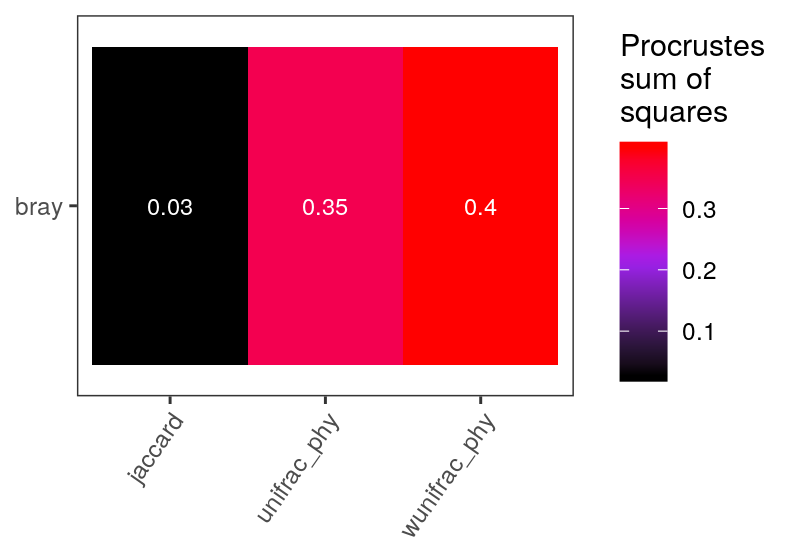

In [41]:
# plotting results
levs = c('jaccard', 'bray', 'unifrac_phy', 'wunifrac_phy', 'unifrac_trt', 'wunifrac_trt')
p = protest_all %>%
    mutate(ss_txt = ifelse(signif < 0.01, gsub('$', '*', round(ss, 2)),
                           as.character(ss)),
           dist_x = dist_x %>% factor(levels=levs),
           dist_y = dist_y %>% factor(levels=levs)) %>%
    ggplot(aes(dist_x, dist_y, fill=ss)) +
    geom_tile() +
    geom_text(aes(label=round(ss, 2)), color='white', size=3) +
    scale_fill_gradientn('Procrustes\nsum of\nsquares', 
                         colors=c('black', 'purple',  'red')) +
    theme_bw() +
    theme(
        panel.grid = element_blank(),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        axis.text.x = element_text(angle=55, hjust=1)
    )

p.dims(4,2.8)
plot(p)

In [ ]:
send_email('http://127.0.0.1:9702/notebooks/ipynb/02_comm_diversity/03_beta-div_procrustes.ipynb')

# sessionInfo

In [42]:
sessionInfo()

R version 3.6.2 (2019-12-12)
Platform: x86_64-conda_cos6-linux-gnu (64-bit)
Running under: Ubuntu 18.04.3 LTS

Matrix products: default
BLAS/LAPACK: /ebio/abt3_projects/Georg_animal_feces/envs/phyloseq/lib/libopenblasp-r0.3.7.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] furrr_0.1.0             future.batchtools_0.8.1 future_1.15.1          
 [4] LeyLabRMisc_0.1.3       vegan_2.5-6             lattice_0.20-38        
 [7] permute_0.9-5           phyloseq_1.30.0         ape_5.3                
[10] purrr_0.3.3             tidytable_0.3.2        